# Mamba / Mamba2 SSD：状态空间模型与注意力的对偶

状态空间模型（SSM）把序列建模成一个**线性动态系统**——本是和注意力并行的另一条技术路线。但 **Mamba2** 的核心
贡献 **SSD（State Space Duality）** 证明了一件深刻的事：**selective SSM 等价于一种带衰减的 masked 注意力**。于是
SSM 与注意力在这里合一，Mamba2 也因此既能像 RNN 一样 $O(T)$ 推理、又能像注意力一样并行训练。

这一章我们把这条对偶一步步推到底：

1. §1 SSM 基础：连续系统 → 离散化 → RNN 式递推；
2. §2 **Mamba1（S6）**：selective —— 让 $B,C,\Delta$ 随输入变化；
3. §3–§4 **Mamba2 SSD**：把 $A$ 标量化，**完整推导** recurrent 形式 ≡ 半可分矩阵（注意力对偶），并数值验证；
4. §5 SSD = **标量衰减 GLA**——它和第 10 章线性注意力是同一个东西；
5. §6–§7 **逐段精读** chunk 实现（块内走对偶、块间走递推）+ 验证本仓库解耦自 fla `simple_gla` 的 kernel。

In [1]:
import sys, math
from pathlib import Path

import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CH = ROOT / "15-mamba"
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(CH))
sys.path.insert(0, str(ROOT / "10-linear-attention"))

from common.nbtools import setup_cjk, show_code
setup_cjk()                                       # 中文字体 + retina 高清出图
from mamba1 import selective_ssm_recurrent
from ssd import ssd_recurrent, ssd_attention_dual
from _fla_ssd_naive import naive_chunk_simple_gla, naive_recurrent_simple_gla
from linear import gla_recurrent                  # 第 10 章 GLA，用于 SSD≡标量衰减GLA 的退化对比

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0))

跑在 NVIDIA GeForce RTX 4090


## 1. SSM 基础：把序列看成线性动态系统

状态空间模型用一个隐状态 $h(t)$ 的线性微分方程描述序列：

$$h'(t)=A\,h(t)+B\,x(t),\qquad y(t)=C\,h(t).$$

要在离散 token 序列上用，先**离散化**（零阶保持 ZOH，步长 $\Delta$）：

$$h_t=\bar A\,h_{t-1}+\bar B\,x_t,\qquad y_t=C\,h_t,\qquad \bar A=e^{\Delta A},\quad \bar B\approx \Delta B.$$

这是一个 RNN 式递推。S4 等早期 SSM 的 $A,B,C,\Delta$ **与输入无关**（线性时不变 LTI），因而可以展开成卷积并行训练——
但代价是**不能按内容选择性地记忆或遗忘**：无论输入什么，状态的更新规则都一样。

## 2. Mamba1（S6）：让 SSM 学会"选择"

Mamba1 的关键改动叫 **selective**：把 $B,C,\Delta$ 变成**随输入 $x$ 变化**的量（data-dependent）。于是模型能根据
token 内容决定"这一步往状态里写多少、用状态的哪部分输出"。代价是不再 LTI、不能用卷积，必须用**硬件感知的
selective scan**。每个特征通道 $d$ 维护一个独立的 $N$ 维对角 SSM（$A$ 是 $(D,N)$ 对角）：

$$h_t[d]=e^{\Delta_t[d]\,A[d]}\odot h_{t-1}[d]+\bigl(\Delta_t[d]\,B_t\bigr)\,x_t[d],\qquad y_t[d]=C_t\cdot h_t[d].$$

$\Delta_t$（softplus 后 $>0$）像一个 data-dependent 的"步长/门"：$\Delta$ 大则 $e^{\Delta A}\to$ 小，快速遗忘旧状态、
重视当前输入；$\Delta$ 小则保留旧状态。下面跑一遍 selective SSM（`mamba1.py`），验证因果性并看状态如何按 $\Delta$ 衰减。

selective SSM 因果性：扰动末尾后前 L-1 步输出 max diff = 0.00e+00（应≈0）


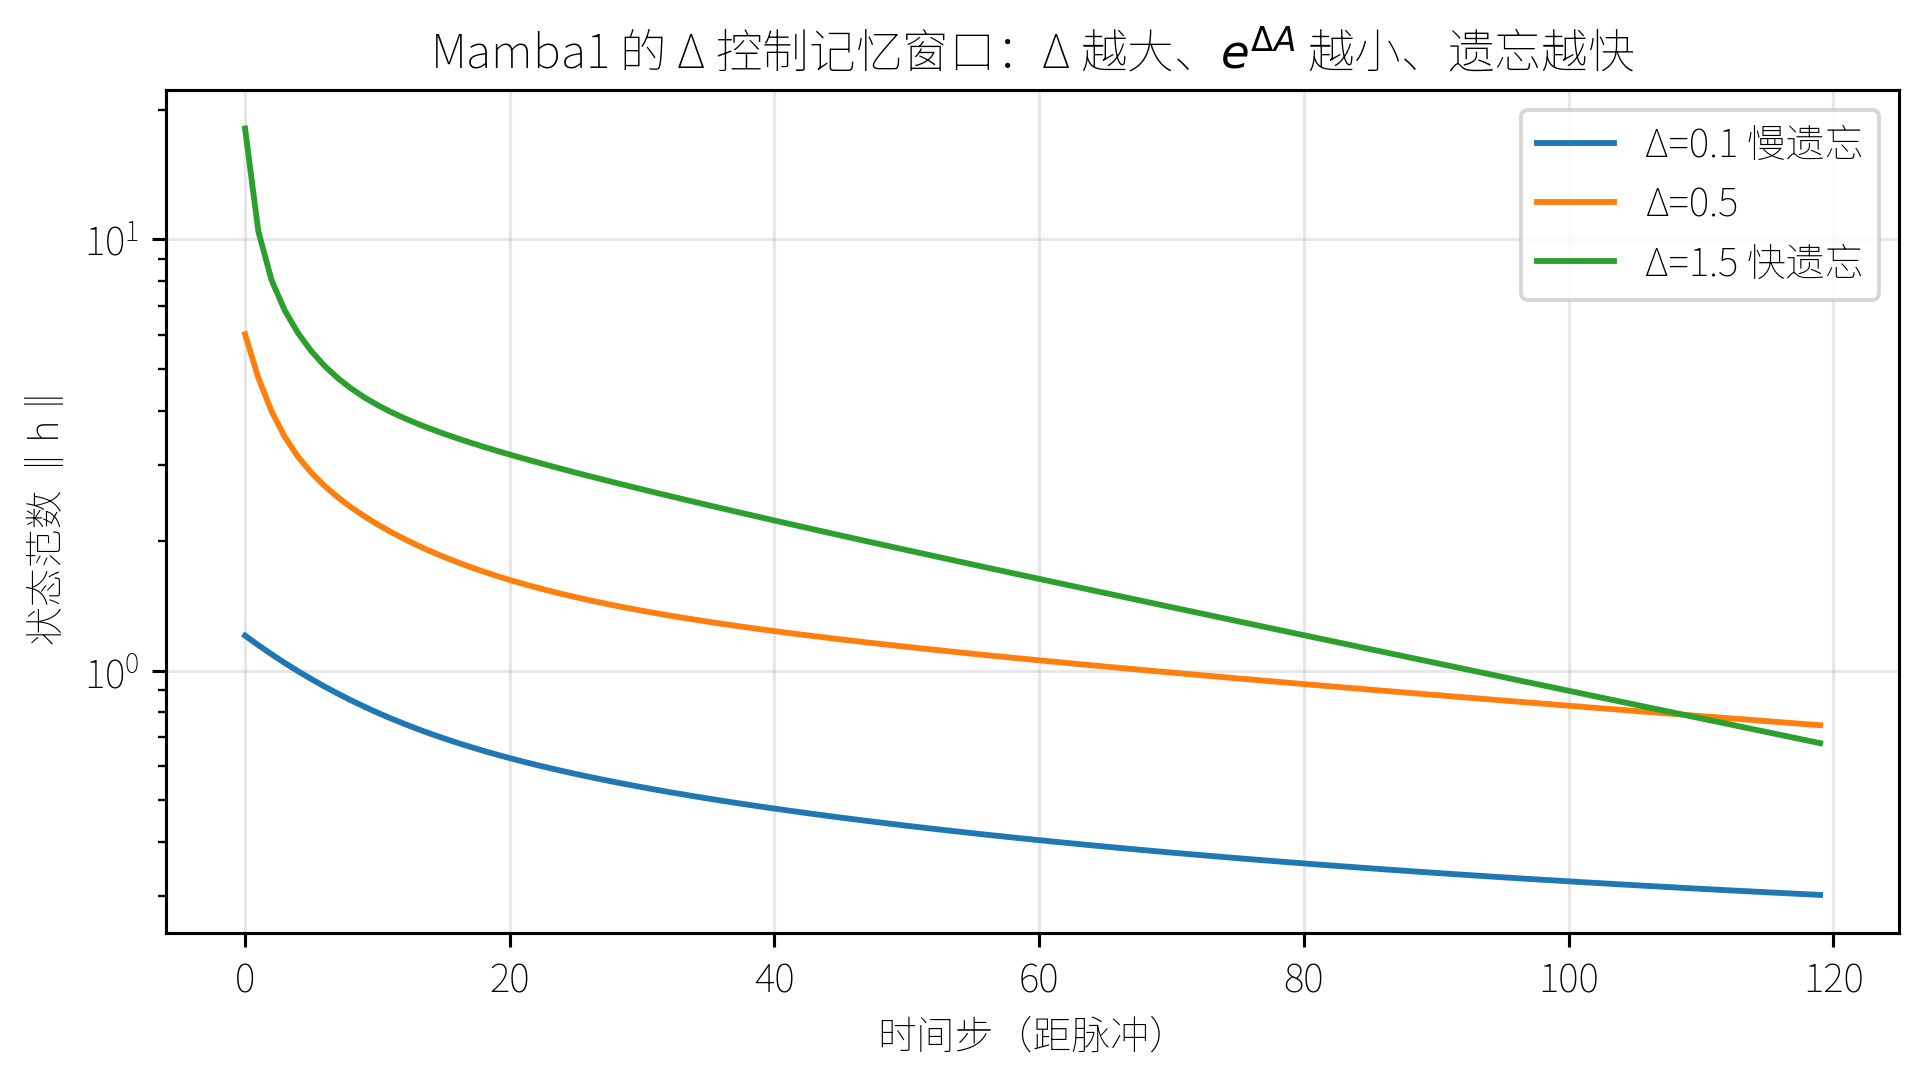

Δ 是 data-dependent 的步长：大 Δ→快遗忘重当前，小 Δ→长记忆。这就是 selective 的'选择'。


In [2]:
bsz, L, D, N = 1, 120, 8, 16
gen = torch.Generator("cuda").manual_seed(0)
x = torch.randn(bsz, L, D, device="cuda", generator=gen)
A = -torch.rand(D, N, device="cuda", generator=gen)               # 负衰减（稳定）
B = torch.randn(bsz, L, N, device="cuda", generator=gen)
C = torch.randn(bsz, L, N, device="cuda", generator=gen)

# 因果性：扰动末尾输入，靠前输出不变
dt = F.softplus(torch.randn(bsz, L, D, device="cuda", generator=gen))
y = selective_ssm_recurrent(x, A, B, C, dt)
x2 = x.clone(); x2[:, -1] += 10.0
y2 = selective_ssm_recurrent(x2, A, B, C, dt)
print(f"selective SSM 因果性：扰动末尾后前 L-1 步输出 max diff = {(y[:, :-1]-y2[:, :-1]).abs().max().item():.2e}（应≈0）")

# Δ 控制记忆：在 t=0 注入脉冲，看状态范数随不同 Δ 的衰减
plt.figure(figsize=(7, 4))
for dt_val, name in [(0.1, "Δ=0.1 慢遗忘"), (0.5, "Δ=0.5"), (1.5, "Δ=1.5 快遗忘")]:
    xp = torch.zeros(1, L, D, device="cuda"); xp[0, 0] = 1.0
    dtc = torch.full((1, L, D), dt_val, device="cuda")
    h_norm = []
    h = torch.zeros(1, D, N, device="cuda")
    Af = A.float()
    for t in range(L):
        dA = (dtc[:, t][..., None] * Af).exp()
        h = dA * h + dtc[:, t][..., None] * B[:, t][:, None, :] * xp[:, t][..., None]
        h_norm.append(h.norm().item())
    plt.plot(h_norm, label=name)
plt.xlabel("时间步（距脉冲）"); plt.ylabel("状态范数 ‖h‖"); plt.yscale("log")
plt.title("Mamba1 的 Δ 控制记忆窗口：Δ 越大、$e^{\\Delta A}$ 越小、遗忘越快"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Δ 是 data-dependent 的步长：大 Δ→快遗忘重当前，小 Δ→长记忆。这就是 selective 的'选择'。")

## 3. Mamba2 SSD：把 $A$ 标量化，换来对偶

Mamba1 的 $A$ 是 $(D,N)$ 对角矩阵，selective scan 只能串行扫描。**Mamba2** 做了一个看似激进的简化：把每个 head 的
$A$ 退化成一个**标量** $a_t=e^{g_t}$（$g_t\le 0$）。再令 $B_t=k_t,\;C_t=q_t,\;x_t=v_t$，把 per-channel 的多个 SSM
合并成一个**矩阵状态** $S\in\mathbb R^{K\times V}$ 的递推：

$$\boxed{\;S_t=e^{g_t}\,S_{t-1}+k_t v_t^\top,\qquad y_t=q_t\,S_t\;}$$

标量衰减看似损失了表达力，却换来一个巨大的好处：状态更新变成了**标量缩放 + 秩-1 外积**，这种结构可以**对偶**成
一个矩阵乘（注意力）。下一节我们把它推出来。

## 4. SSD 对偶：recurrent ≡ 半可分矩阵（完整推导）

### 4.1 把递推展开

从 $S_t=e^{g_t}S_{t-1}+k_tv_t^\top$、$S_0$ 起，逐步代入（设 $g^{\mathrm{cum}}_t=\sum_{l\le t} g_l$ 为前缀和）：

$$
S_t=\sum_{j\le t}\Big(\prod_{j<l\le t} e^{g_l}\Big)k_jv_j^\top
   =\sum_{j\le t} e^{\,g^{\mathrm{cum}}_t-g^{\mathrm{cum}}_j}\,k_jv_j^\top.
$$

代进输出 $y_t=q_tS_t$：

$$
y_t=q_t\sum_{j\le t} e^{\,g^{\mathrm{cum}}_t-g^{\mathrm{cum}}_j}\,k_jv_j^\top
   =\sum_{j\le t}\underbrace{e^{\,g^{\mathrm{cum}}_t-g^{\mathrm{cum}}_j}}_{\text{衰减}}\underbrace{(q_t^\top k_j)}_{\text{注意力分数}}\,v_j.
$$

### 4.2 写成矩阵：半可分矩阵

把所有 $t$ 摞起来，$y_t$ 的求和正是一个矩阵乘 $Y=MV$，其中

$$M_{ij}=\underbrace{e^{\,g^{\mathrm{cum}}_i-g^{\mathrm{cum}}_j}}_{L_{ij}}\,(q_i^\top k_j)\quad(i\ge j),\qquad M=L\circ(QK^\top).$$

$L$ 是"累积衰减下三角"，$M=L\circ(QK^\top)$ 就是**带衰减的 causal 注意力分数矩阵**。$M$ 有特殊结构——它是
**1-semiseparable（半可分）矩阵**：下三角部分每个元素能写成 $q_i^\top(\text{对角缩放})k_j$，正是这个结构让"矩阵乘
(注意力)"和"标量递推 (SSM)"互为对偶。

### 4.3 两种形式，一个结果

- **线性 / recurrent 形式**（`ssd_recurrent`）：$S_t=e^{g_t}S_{t-1}+k_tv_t^\top$ —— $O(T)$ 推理、$O(1)$ 内存；
- **注意力 / 对偶形式**（`ssd_attention_dual`）：$Y=(L\circ QK^\top)V$ —— $O(T^2)$ 但可并行训练。

下面数值验证它们**精确相等**，并把半可分矩阵 $M$ 画出来。

SSD recurrent ≡ attention-dual   max diff = 4.39e-05  ✓ 对偶成立


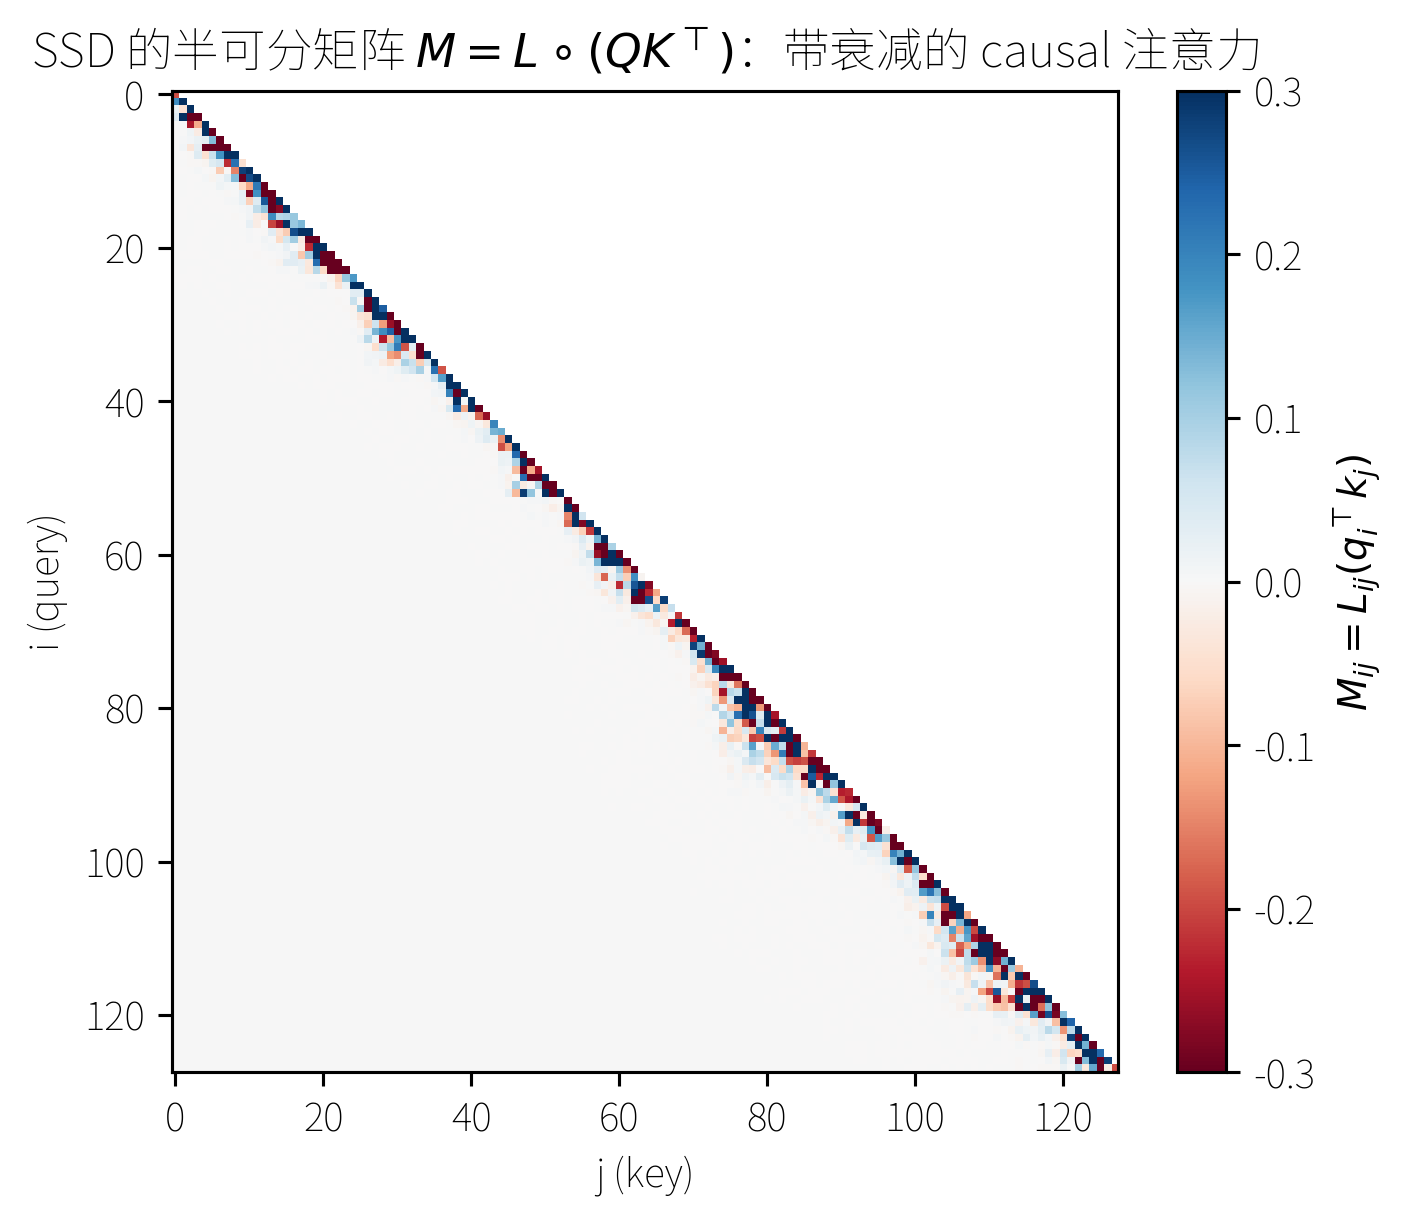

下三角的衰减注意力矩阵 M；y=MV 与 SSM 递推等价——这就是 SSD 对偶。


In [3]:
B, H, T, D = 2, 4, 128, 64
gen = torch.Generator("cuda").manual_seed(0)
q = torch.randn(B, H, T, D, device="cuda", generator=gen)
k = torch.randn(B, H, T, D, device="cuda", generator=gen)
v = torch.randn(B, H, T, D, device="cuda", generator=gen)
g = F.logsigmoid(torch.randn(B, H, T, device="cuda", generator=gen))

o_rec = ssd_recurrent(q, k, v, g)
o_dual = ssd_attention_dual(q, k, v, g)
print(f"SSD recurrent ≡ attention-dual   max diff = {(o_rec-o_dual).abs().max().item():.2e}  ✓ 对偶成立")

# 可视化半可分矩阵 M = L ∘ (QK^T)（取一个 head）
scale = D ** -0.5
g_cum = g[0, 0].cumsum(0)
A_qk = (q[0, 0] @ k[0, 0].T) * scale
L = (g_cum[:, None] - g_cum[None, :]).exp().tril()
M = (A_qk * L).detach().cpu()
M_show = M.clone(); M_show[M_show == 0] = float("nan")        # 上三角(未来)画空白
plt.figure(figsize=(5.2, 4.5))
plt.imshow(M_show, cmap="RdBu", vmin=-0.3, vmax=0.3, aspect="auto")
plt.colorbar(label="$M_{ij}=L_{ij}(q_i^\\top k_j)$"); plt.xlabel("j (key)"); plt.ylabel("i (query)")
plt.title("SSD 的半可分矩阵 $M=L\\circ(QK^\\top)$：带衰减的 causal 注意力")
plt.tight_layout(); plt.show()
print("下三角的衰减注意力矩阵 M；y=MV 与 SSM 递推等价——这就是 SSD 对偶。")

## 5. SSD 就是"标量衰减的 GLA"

回看 SSD 的递推 $S_t=e^{g_t}S_{t-1}+k_tv_t^\top$，和第 10 章 **GLA** 的 $S_t=\operatorname{diag}(e^{g_t})S_{t-1}+k_tv_t^\top$
只差一处：**衰减门 $g_t$ 的粒度**——

- **GLA**：$g_t\in\mathbb R^K$ 是 per-channel 向量（$\operatorname{diag}(e^{g_t})$，每个 key 通道独立衰减）；
- **SSD**：$g_t\in\mathbb R$ 是 per-head 标量（$e^{g_t}$，整个状态统一衰减）。

所以 **SSD = 标量衰减的 GLA**。fla 索性把它实现为 `simple_gla`（"simplified GLA"）。验证：把 SSD 的标量 $g$ **广播**到
所有通道喂给 GLA，应得到与 SSD 相同的结果。

In [4]:
B, H, T, D = 2, 4, 128, 64
gen = torch.Generator("cuda").manual_seed(1)
q = torch.randn(B, H, T, D, device="cuda", generator=gen)
k = torch.randn(B, H, T, D, device="cuda", generator=gen)
v = torch.randn(B, H, T, D, device="cuda", generator=gen)
g_scalar = F.logsigmoid(torch.randn(B, H, T, device="cuda", generator=gen))    # SSD 的 per-head 标量

o_ssd = ssd_recurrent(q, k, v, g_scalar)
o_gla = gla_recurrent(q, k, v, g_scalar[..., None].expand(B, H, T, D))         # 标量 g 广播到 per-channel
print(f"SSD(标量g) ≡ GLA(广播g)   max diff = {(o_ssd-o_gla).abs().max().item():.2e}")
print("→ SSD 是 GLA 的标量衰减特例。'状态空间'与'线性注意力'两条线，在这里是同一个递推。")

SSD(标量g) ≡ GLA(广播g)   max diff = 9.54e-07
→ SSD 是 GLA 的标量衰减特例。'状态空间'与'线性注意力'两条线，在这里是同一个递推。


### 5.1 线性家族行为全家福：累加 vs 遗忘 vs 覆盖

把前面线性线/SSM 的几种"状态管理"放到**同一个任务**上对比，一眼看清本质区别。任务：固定一个 key $k=e_0$，在
$t=0$ 写入 $v_0=e_1$、在 $t=20$ 用**同一个 key** 写入 $v_1=e_2$（其余步不写），之后每步用 $k$ 查询，看读出在
$v_0,v_1$ 两个方向的分量随时间怎么变。三种机制会给出三种截然不同的行为。

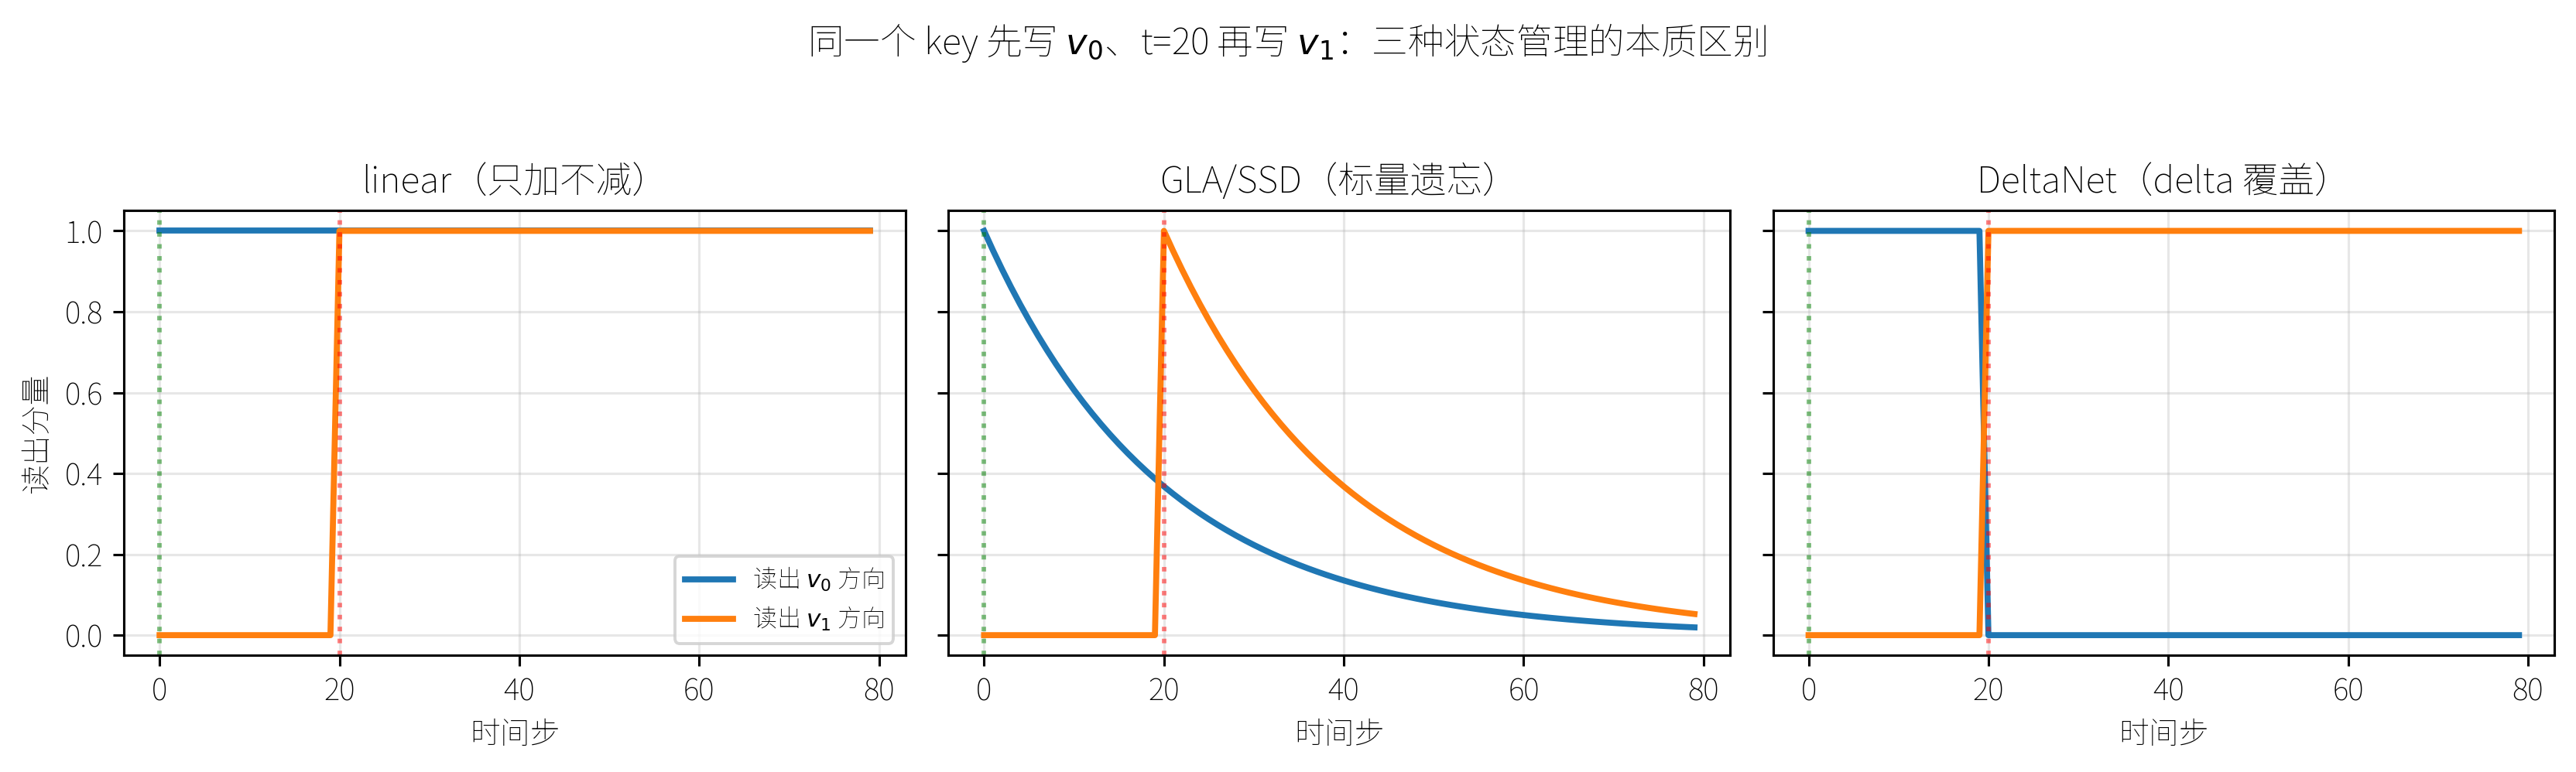

linear：v0 写进去就永远在（t=20 后 v0、v1 都≈1，累加，分不清新旧）；
GLA/SSD：v0、v1 都按指数遗忘（标量衰减，旧信息自然淡出）；
DeltaNet：t=20 用同一 key 写 v1 时**擦掉**了 v0（v0→0、v1=1），实现'覆盖更新'——delta 的独门绝技。


In [5]:
import sys as _sys
_sys.path.insert(0, str(ROOT / "11-deltanet"))
from deltanet import delta_rule_recurrent

T, D = 80, 16
dev = "cuda"
k = torch.zeros(1, 1, T, D, device=dev)
k[0, 0, 0, 0] = 1.0; k[0, 0, 20, 0] = 1.0                       # key=e0 只在两次写入时刻出现（其余步 k=0 不写不读）
q = torch.zeros(1, 1, T, D, device=dev); q[0, 0, :, 0] = 1.0     # 每步都用 e0 查询
v = torch.zeros(1, 1, T, D, device=dev)
v[0, 0, 0, 1] = 1.0                                              # t=0  写 v0 = e1
v[0, 0, 20, 2] = 1.0                                            # t=20 用同一 key 写 v1 = e2

o_lin = ssd_recurrent(q, k, v, torch.zeros(1, 1, T, device=dev), scale=1.0)             # g=0 的 SSD = 朴素 linear
o_ssd = ssd_recurrent(q, k, v, torch.full((1, 1, T), -0.05, device=dev), scale=1.0)    # 标量遗忘
o_delta = delta_rule_recurrent(q, k, v, torch.ones(1, 1, T, device=dev), l2norm=False, scale=1.0)  # delta 覆盖

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, o, name in [(axes[0], o_lin, "linear（只加不减）"),
                    (axes[1], o_ssd, "GLA/SSD（标量遗忘）"),
                    (axes[2], o_delta, "DeltaNet（delta 覆盖）")]:
    ax.plot(o[0, 0, :, 1].cpu(), label="读出 $v_0$ 方向", lw=2)
    ax.plot(o[0, 0, :, 2].cpu(), label="读出 $v_1$ 方向", lw=2)
    ax.axvline(0, color="g", ls=":", alpha=0.5); ax.axvline(20, color="r", ls=":", alpha=0.5)
    ax.set_title(name); ax.set_xlabel("时间步"); ax.grid(alpha=0.3)
axes[0].set_ylabel("读出分量"); axes[0].legend(fontsize=8)
plt.suptitle("同一个 key 先写 $v_0$、t=20 再写 $v_1$：三种状态管理的本质区别", y=1.04)
plt.tight_layout(); plt.show()
print("linear：v0 写进去就永远在（t=20 后 v0、v1 都≈1，累加，分不清新旧）；")
print("GLA/SSD：v0、v1 都按指数遗忘（标量衰减，旧信息自然淡出）；")
print("DeltaNet：t=20 用同一 key 写 v1 时**擦掉**了 v0（v0→0、v1=1），实现'覆盖更新'——delta 的独门绝技。")

## 6. 逐段精读：chunk 实现 = 块内对偶 + 块间递推

生产 kernel 既不用纯 recurrent（$O(T)$ 串行慢），也不用纯对偶（$O(T^2)$ 费），而是**chunk**：把序列切块，**块内**走
对偶形式（小矩阵乘，并行），**块间**走 recurrent（传一个状态 $S$）。这正好结合两种形式的优点。对应代码是 fla 参考
实现 `naive_chunk_simple_gla`（本仓库 `_fla_ssd_naive.py`），拆成 2 段看：

### 6.1 分块 + 块内半可分矩阵 $L$

```python
# _fla_ssd_naive.py · naive_chunk_simple_gla（节选）
q, k, v, decay = map(lambda x: rearrange(x, 'b h (n c) d -> b h n c d', c=chunk_size), ...)
decay = decay.squeeze(-1).cumsum(-1)                          # 块内 g 前缀和 g^cum
L_mask = ((decay.unsqueeze(-1) - decay.unsqueeze(-2)).tril().exp()).tril()   # 块内 L_ij=exp(g^cum_i-g^cum_j)
```

这就是 §4.2 的 $L_{ij}=e^{g^{\mathrm{cum}}_i-g^{\mathrm{cum}}_j}$，只不过限制在**块内**（每块 $C$ 个位置）。块内用它做对偶。

### 6.2 块间循环：块内对偶 + 块间递推

```python
S = zeros(B, H, K, V)                                         # 跨块状态
for i in range(NT):
    q_i, k_i, v_i = q[:,:,i], k[:,:,i], v[:,:,i]
    attn = (q_i @ k_i.transpose(-1,-2)) * L_mask[:,:,i]       # ① 块内对偶：M=L∘(QKᵀ)
    o_inter = (q_i * decay[:,:,i,:,None].exp()) @ S           # ② 块间：q 衰减后读起点状态 S
    o[:,:,i] = o_inter + attn @ v_i                          #    输出 = 块内 + 块间
    S = S * decay[:,:,i,-1,None,None].exp() + \              # ③ 状态递推到下一块
        (k_i * (decay[:,:,i,-1,None]-decay[:,:,i]).exp()[...,None]).transpose(-1,-2) @ v_i
```

**① 块内**用 §4 的对偶形式 $\text{attn}=L\circ(QK^\top)$、$\text{attn}\cdot v$（小 $C\times C$ 矩阵乘，并行）；**②③ 块间**用
§3 的 recurrent（状态 $S$ 按块末累积衰减传递）。$NT$ 个块之间只有一条 $S$ 的串行链（$O(T/C)$），块内全并行——这就是
Mamba2 的 chunk scan。下面验证它与纯 recurrent 等价。

> **真实 Triton 对应**：块内对偶 + 输出在 `_fla_ssd_chunk_o.py`；块间状态递推在 `_fla_ssd_chunk_h.py`；门控前缀和在
> `_fla_ssd_cumsum.py`。

In [6]:
B, T, H, D = 2, 256, 4, 64
gen = torch.Generator("cuda").manual_seed(2)
q = torch.randn(B, T, H, D, device="cuda", generator=gen)
k = torch.randn(B, T, H, D, device="cuda", generator=gen)
v = torch.randn(B, T, H, D, device="cuda", generator=gen)
g = F.logsigmoid(torch.randn(B, T, H, device="cuda", generator=gen))
o_chunk, _ = naive_chunk_simple_gla(q, k, v, g, chunk_size=64)        # 块内对偶 + 块间递推
o_rec, _ = naive_recurrent_simple_gla(q, k, v, g)                      # 纯 recurrent
print(f"chunk(块内对偶+块间递推) vs recurrent   max diff = {(o_chunk-o_rec).abs().max().item():.2e}")
print("→ chunk 把 SSD 两种形式拼起来：块内对偶（并行）、块间递推（线性），与纯 recurrent 等价。")

chunk(块内对偶+块间递推) vs recurrent   max diff = 1.72e-05
→ chunk 把 SSD 两种形式拼起来：块内对偶（并行）、块间递推（线性），与纯 recurrent 等价。


## 7. 真实 Triton kernel：完整解耦自 fla simple_gla

本仓库**完整拷贝并解耦** Mamba2 SSD 的 4 个 triton 文件（`chunk` + common `chunk_h`/`chunk_o` + `cumsum`），靠
**no-op dispatch** 脱离 fla 独立运行（比 KDA/GDN 简单，无 cp stub）。下面保留**完整源码**——SSD chunk 入口
`_fla_ssd_chunk.py`（可滚动），其余 3 个文件见 [`SOURCES.md`](./SOURCES.md)。

In [7]:
show_code(str(CH / "_fla_ssd_chunk.py"))

### 数值验证：解耦没改任何计算（bitwise ≡ fla）

In [8]:
from _fla_ssd_chunk import chunk_simple_gla as local
B, T, H, D = 2, 512, 4, 64
gg = torch.Generator("cuda").manual_seed(1)
q = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
k = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
v = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
g = F.logsigmoid(torch.randn(B, T, H, device="cuda", dtype=torch.float32, generator=gg))

ol, _ = local(q, k, v, g)
try:
    from fla.ops.simple_gla import chunk_simple_gla as flak
    of, _ = flak(q, k, v, g)
    print(f"① 定长：本地解耦 vs fla 原版   max diff: {(ol.float()-of.float()).abs().max().item():.2e}  bitwise: {torch.equal(ol, of)}")
    cu = torch.tensor([0, 200, 512, 800, 1024], device="cuda", dtype=torch.int32)
    qp, kp, vp = (x.reshape(1, B * T, H, D) for x in (q, k, v)); gp = g.reshape(1, B * T, H)
    o2, _ = local(qp, kp, vp, gp, cu_seqlens=cu)
    f2, _ = flak(qp, kp, vp, gp, cu_seqlens=cu)
    print(f"② 变长(cu_seqlens)：本地 vs fla    max diff: {(o2.float()-f2.float()).abs().max().item():.2e}  bitwise: {torch.equal(o2, f2)}")
except ImportError:
    print("（未装 fla，跳过原版对照）")
print("→ 完整解耦（4 文件 + no-op dispatch）没改任何计算：与 fla simple_gla bitwise 一致。")

① 定长：本地解耦 vs fla 原版   max diff: 0.00e+00  bitwise: True


② 变长(cu_seqlens)：本地 vs fla    max diff: 0.00e+00  bitwise: True
→ 完整解耦（4 文件 + no-op dispatch）没改任何计算：与 fla simple_gla bitwise 一致。


## 8. 反向传播：最简的 chunk backward

§1–§7 都在讲 forward；训练靠 backward。SSD 的 backward 是这一系列里**最简单的**——因为它**没有 delta 擦除**
（$S_t=e^{g_t}S_{t-1}+k_tv_t^\top$，没有 $(I-\beta kk^\top)$），于是 **没有 WY 求逆那一块**（对比第 11–13 章 DeltaNet/KDA/GDN）。
只剩两块：

1. **块内**标准矩阵乘反向（半可分矩阵 $M=L\circ(QK^\top)$ 与 $o=\hat Q S+Mv$）；
2. 状态 $S$ 块间**串行 carry** → **反向扫描**（BPTT，从后往前累积状态梯度 $dS$），并把 per-head 标量门控梯度 $dg$ 汇回。

下面手推**完整 backward** 用 autograd **逐位钉死**。

### 8.1 两个关键反向（无 WY 求逆）

记 forward（块 $n$，$S$ 为进入该块的状态，$\gamma=g$ 的块内前缀和、per-head 标量）：

$$L_{ij}=e^{\gamma_i-\gamma_j}\ (i\ge j,\ \text{否则}\ 0),\quad A_n=(Q_nK_n^\top)\circ L,\quad o_n=\hat Q_n\,S+A_n v_n,\quad \hat Q_n=Q_n\odot e^{\gamma},$$
$$S'=e^{\gamma_{\text{last}}}\,S+k_{\text{tail}}^\top v_n,\qquad k_{\text{tail}}=k\odot e^{\gamma_{\text{last}}-\gamma}.$$

**① 块内（标准矩阵乘反向）**：由 $o_n=\hat Q_n S+A_n v_n$ 得 $d\hat Q_n=do_n\,S^\top$、$dA_n=do_n\,v_n^\top$、
$dv_n\mathrel{+}=A_n^\top do_n$；$A_n=(QK^\top)\circ L$ 再反传出 $dQ,dK$ 与 $dL$（$dL$ 汇回 $dg$）。

**② 块间反向扫描（BPTT）**：$S'=e^{\gamma_{\text{last}}}S+k_{\text{tail}}^\top v_n$ 把状态梯度 $dS$ 从后往前传——

$$dS\mathrel{+}=e^{\gamma_{\text{last}}}\,dS',\qquad dk_{\text{tail}}=v_n\,dS'^\top,\qquad dv_n\mathrel{+}=k_{\text{tail}}\,dS'.$$

**从 $n=N{-}1$ 倒扫到 $0$**，$dS$ 一路累积——这正是 RNN 的 BPTT。**门控梯度 $dg$**：$\hat Q,k_{\text{tail}},L,e^{\gamma_{\text{last}}}$ 里的指数项
把梯度汇成 $d\gamma$，再 $dg=\operatorname{rev\_cumsum}(d\gamma)$（前缀和的反向 = 后缀和）。

In [9]:
# 手推 SSD chunk backward，用 autograd 逐位钉死。SSD 无 delta 擦除 → 没有 WY 求逆，是最简的 chunk backward：
# 只有 ① 块内标准矩阵乘反向 + ② 块间 BPTT 反向扫描（含 per-head 标量门控梯度 dg）。
dev = "cuda"
B_, H_, T_, D_, C_ = 1, 1, 12, 4, 4
N_ = T_ // C_
strict = torch.triu(torch.ones(C_, C_, device=dev), 1).bool()      # 严格上三角（A 要置 0）

def fwd(q, k, v, g, store):
    qc, kc, vc, gc = (x.view(B_, H_, N_, C_, -1) for x in (q, k, v, g.unsqueeze(-1)))
    o = torch.zeros(B_, H_, N_, C_, D_, device=dev); S = torch.zeros(B_, H_, D_, D_, device=dev)
    for n in range(N_):
        qn, kn, vn = qc[:, :, n], kc[:, :, n], vc[:, :, n]; gn = gc[:, :, n, :, 0]        # gn: (B,H,C) 标量门控
        gam = gn.cumsum(-1); E = gam.exp(); glast = gam[..., -1]                          # g^cum 块内前缀和（标量）
        L = (gam[..., :, None] - gam[..., None, :]).exp().masked_fill(strict, 0.)         # L_ij=e^{g_i-g_j}（causal）
        A = (qn @ kn.transpose(-1, -2)) * L                                               # 半可分：M=L∘(QK^T)
        hq = qn * E[..., None]                                                            # q∘e^{g^cum}
        o[:, :, n] = hq @ S + A @ vn                                                      # 块间读出 + 块内对偶
        Ktail = kn * (glast[..., None] - gam).exp()[..., None]
        store.append(dict(qn=qn, kn=kn, vn=vn, gam=gam, E=E, glast=glast, L=L, A=A, hq=hq, Sn=S.clone(), Ktail=Ktail))
        S = E[..., -1][..., None, None] * S + Ktail.transpose(-1, -2) @ vn                # 块间状态递推
    return o.view(B_, H_, T_, D_)

def bwd(do, store):
    doc = do.view(B_, H_, N_, C_, D_)
    dq = torch.zeros(B_, H_, N_, C_, D_, device=dev); dk = torch.zeros_like(dq); dv = torch.zeros_like(dq)
    dg = torch.zeros(B_, H_, N_, C_, device=dev); dS = torch.zeros(B_, H_, D_, D_, device=dev)
    for n in reversed(range(N_)):
        s = store[n]
        qn, kn, vn, gam, E, glast, L, A, hq, Sn, Ktail = (s[x] for x in
            ("qn", "kn", "vn", "gam", "E", "glast", "L", "A", "hq", "Sn", "Ktail"))
        do_n = doc[:, :, n]; dgam = torch.zeros_like(gam)
        El = E[..., -1]                                                                   # ② 块间 BPTT 反向扫描
        dS_state = El[..., None, None] * dS; dEl = (Sn * dS).sum((-1, -2))
        dKtail = vn @ dS.transpose(-1, -2); dv[:, :, n] = Ktail @ dS
        dglast = dEl * El; dk[:, :, n] = dKtail * (glast[..., None] - gam).exp()[..., None]
        tmp = dKtail * Ktail; dglast = dglast + tmp.sum((-1, -2)); dgam = dgam - tmp.sum(-1)
        dhq = do_n @ Sn.transpose(-1, -2); dS_state = dS_state + hq.transpose(-1, -2) @ do_n   # ① 块内
        dA = do_n @ vn.transpose(-1, -2); dv[:, :, n] = dv[:, :, n] + A.transpose(-1, -2) @ do_n
        dq[:, :, n] = dhq * E[..., None]; dgam = dgam + (dhq * hq).sum(-1)                 # hq=q∘e^{g^cum}
        G = dA * L; dq[:, :, n] = dq[:, :, n] + G @ kn; dk[:, :, n] = dk[:, :, n] + G.transpose(-1, -2) @ qn
        dLL = dA * (qn @ kn.transpose(-1, -2)) * L                                         # A=(QK^T)∘L → d(g_i-g_j)
        dgam = dgam + dLL.sum(-1) - dLL.sum(-2)                                            # 行和(i) - 列和(j)
        dgam[..., -1] = dgam[..., -1] + dglast
        dg[:, :, n] = dgam.flip(-1).cumsum(-1).flip(-1)                                    # 前缀和的反向 = 后缀和
        dS = dS_state
    return (x.reshape(B_, H_, T_, D_) for x in (dq, dk, dv)), dg.reshape(B_, H_, T_)

torch.manual_seed(0)
q = torch.randn(B_, H_, T_, D_, device=dev, requires_grad=True); k = torch.randn(B_, H_, T_, D_, device=dev, requires_grad=True)
v = torch.randn(B_, H_, T_, D_, device=dev, requires_grad=True); g = F.logsigmoid(torch.randn(B_, H_, T_, device=dev)).requires_grad_(True)
store = []; o = fwd(q, k, v, g, store); do = torch.randn_like(o); o.backward(do)
o_rec = ssd_recurrent(q, k, v, g, scale=1.0)
print(f"可微 chunk fwd vs ssd_recurrent      max diff = {(o.detach() - o_rec).abs().max().item():.2e}")
(dq_m, dk_m, dv_m), dg_m = bwd(do, store)
for nm, a, b in [("dq", dq_m, q.grad), ("dk", dk_m, k.grad), ("dv", dv_m, v.grad), ("dg", dg_m, g.grad)]:
    print(f"{nm}: 手推 vs autograd  max diff = {(a - b).abs().max().item():.2e}")
print("→ 手推 backward（块间 BPTT 反向扫描 + 标量门控 dg + 块内）与 autograd 逐位一致；SSD 无 WY 求逆，最简。")

可微 chunk fwd vs ssd_recurrent      max diff = 4.77e-07
dq: 手推 vs autograd  max diff = 0.00e+00
dk: 手推 vs autograd  max diff = 0.00e+00
dv: 手推 vs autograd  max diff = 0.00e+00
dg: 手推 vs autograd  max diff = 4.77e-07
→ 手推 backward（块间 BPTT 反向扫描 + 标量门控 dg + 块内）与 autograd 逐位一致；SSD 无 WY 求逆，最简。


### 8.2 对应到真实 kernel

SSD（= fla `simple_gla`）的 backward 没有 WY 求逆，比 DeltaNet 系少一整块：

| 手推的反向 | fla bwd kernel |
|---|---|
| ② 块间反向扫描（$dS$、$dh$） | `_fla_ssd_chunk_h.py :: chunk_bwd_dh`（由 `chunk_simple_gla_bwd` 编排） |
| ① 块内 $dq/dk/dg$ 与 $dv$ | `_fla_ssd_chunk_o.py :: chunk_bwd_dqkwg / chunk_bwd_dv` |
| 门控前缀和的反向 | `_fla_ssd_cumsum.py`（后缀和） |

对比第 11–13 章（DeltaNet / KDA / GDN），SSD 少了 **WY 求逆梯度**那一块——这正是"无 delta 擦除"在反向上的直接体现。
线性家族里"擦除"越复杂，backward 就越重。

### 变长序列（cu_seqlens）—— 本章 kernel 同样支持

和第 10 章 GLA 一样，本章 kernel 原生支持**变长**：多条不等长序列 packing 成一条（`batch=1`）+ `cu_seqlens` 标记边界，
内部用 `prepare_chunk_indices` 让块不跨序列、状态在每条序列开头重置。**完整原理与图示见第 10 章 §6**；这里只验证本章
`chunk_simple_gla` 同样满足"packed 一次 == 逐条单独跑"。

In [10]:
H, D = 4, 64
lens = [100, 250, 160]; total = sum(lens)                       # 3 条不等长序列
cu = torch.tensor([0, 100, 350, 510], device="cuda", dtype=torch.int32)
gg = torch.Generator("cuda").manual_seed(7)
qv = torch.randn(1, total, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
kv = torch.randn(1, total, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
vv = torch.randn(1, total, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
from _fla_ssd_chunk import chunk_simple_gla
gv = torch.nn.functional.logsigmoid(torch.randn(1, total, H, device="cuda", generator=gg))
o_packed = chunk_simple_gla(qv, kv, vv, gv, cu_seqlens=cu)[0]                                          # (a) packed 一次：传 cu_seqlens
o_each = []                                                     # (b) 逐条单独当定长各跑一次
for i in range(len(lens)):
    s, e = cu[i].item(), cu[i + 1].item()
    o_each.append(chunk_simple_gla(qv[:, s:e].contiguous(), kv[:, s:e].contiguous(), vv[:, s:e].contiguous(), gv[:, s:e].contiguous())[0])
o_each = torch.cat(o_each, dim=1)
print(f"packed(cu_seqlens 一次) vs 逐条单独跑   max diff: {(o_packed - o_each).abs().max().item():.2e}")
print("→ packed≡逐条（bf16 逐位一致）：块不跨序列、状态在每条序列开头重置。变长完整原理见第 10 章 §6。")

packed(cu_seqlens 一次) vs 逐条单独跑   max diff: 0.00e+00
→ packed≡逐条（bf16 逐位一致）：块不跨序列、状态在每条序列开头重置。变长完整原理见第 10 章 §6。


## 9. 复杂度：$O(S)$ vs full attention $O(S^2)$

SSD（标量衰减线性注意力）线性复杂度，标量衰减比 GLA 的 per-channel 门控更轻。

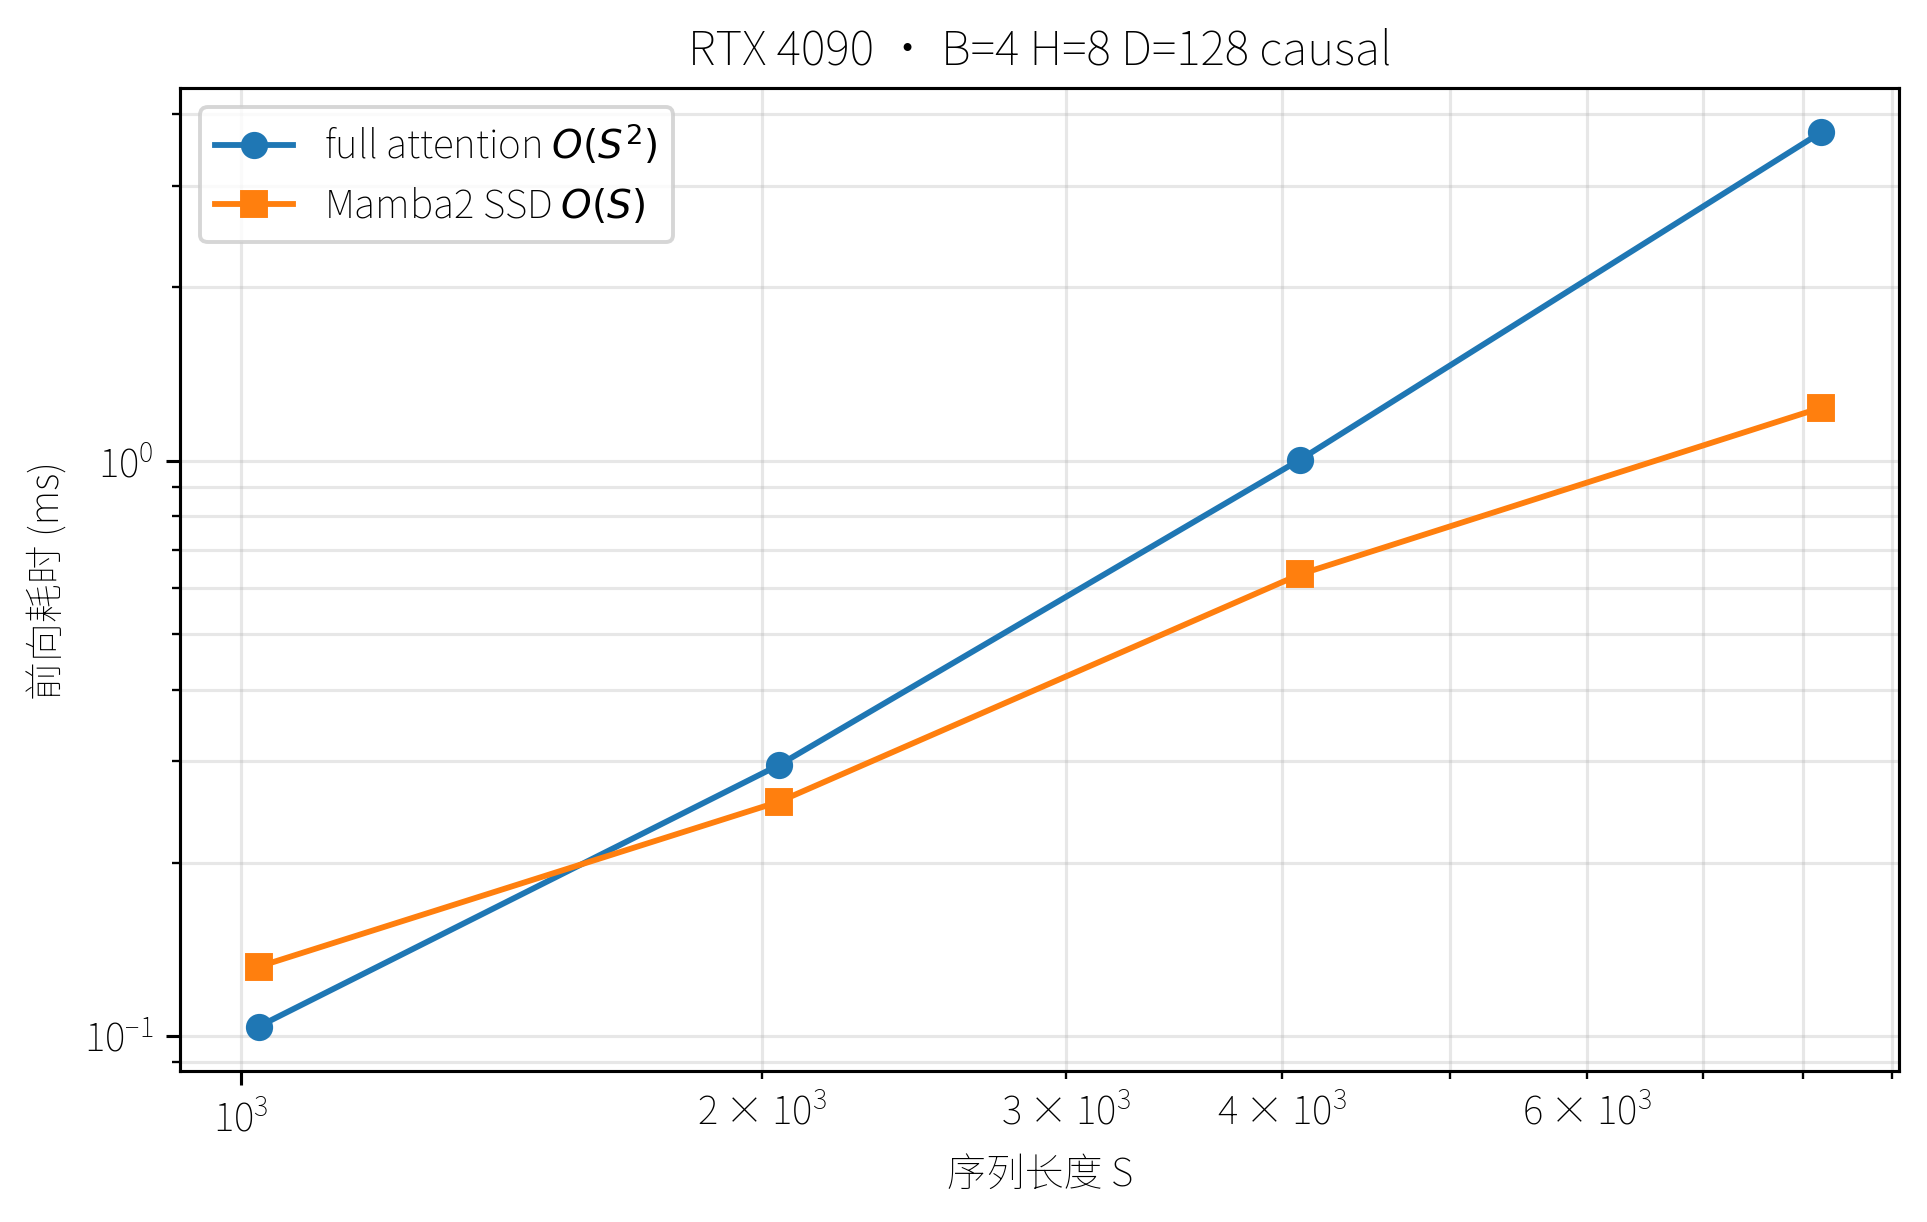

S= 1024  full  0.104ms  SSD  0.132ms (0.79×)
S= 2048  full  0.296ms  SSD  0.255ms (1.16×)
S= 4096  full  1.004ms  SSD  0.634ms (1.58×)
S= 8192  full  3.720ms  SSD  1.235ms (3.01×)


In [11]:
from common import bench_ms
from ssd_triton import ssd_chunk

B, H, D = 4, 8, 128
Ss = [1024, 2048, 4096, 8192]
full, ssd_t = [], []
for S in Ss:
    q = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    k = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    v = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    qb, kb, vb = (x.to(torch.bfloat16) for x in (q, k, v))
    g = F.logsigmoid(torch.randn(B, H, S, device="cuda", dtype=torch.float32))
    full.append(bench_ms(lambda: F.scaled_dot_product_attention(q, k, v, is_causal=True)))
    ssd_t.append(bench_ms(lambda: ssd_chunk(qb, kb, vb, g)))

plt.figure(figsize=(7, 4.5))
plt.plot(Ss, full, "o-", label="full attention $O(S^2)$")
plt.plot(Ss, ssd_t, "s-", label="Mamba2 SSD $O(S)$")
plt.xlabel("序列长度 S"); plt.ylabel("前向耗时 (ms)"); plt.yscale("log"); plt.xscale("log")
plt.title("RTX 4090 · B=4 H=8 D=128 causal"); plt.legend(); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
for i, S in enumerate(Ss):
    print(f"S={S:>5}  full {full[i]:6.3f}ms  SSD {ssd_t[i]:6.3f}ms ({full[i]/ssd_t[i]:.2f}×)")

## 🛠 动手练习

1. **对偶更长**：在更长序列（`S=2048`）上验证 `ssd_recurrent ≡ ssd_attention_dual`，看半可分矩阵对偶是否依然精确（应仍到机器精度）。
2. **变成 GLA**：把 SSD 的 per-head 标量 `g` 换成 per-channel（广播到 K 维喂给 `gla_recurrent`），它就是第 10 章的 GLA——对比输出，体会 "SSD = 标量衰减 GLA"。
3. **selective 的记忆**：把 Mamba1 的 $\Delta$ 整体调大/调小，重做 §2 的状态衰减实验，看 selective SSM 的记忆窗口如何随 $\Delta$ 伸缩。

## 10. 收尾

Mamba 这一章把"状态空间"和"注意力"两条线接到了一起：

1. **SSM 基础**（§1）：序列 = 线性动态系统，离散化成 RNN 式递推；
2. **Mamba1 selective**（§2）：让 $B,C,\Delta$ data-dependent，模型学会按内容选择记忆（selective scan）；
3. **Mamba2 SSD 对偶**（§3–§4）：把 $A$ 标量化后，recurrent 形式 $S_t=e^{g_t}S_{t-1}+k_tv_t^\top$ **精确等价于**半可分
   矩阵 $Y=(L\circ QK^\top)V$——SSM 既是递推也是注意力；
4. **SSD = 标量衰减 GLA**（§5）：和第 10 章线性注意力是同一个递推，只差衰减门的粒度；
5. **chunk + 真实 kernel**（§6–§7）：块内对偶、块间递推，本仓库完整解耦自 fla `simple_gla`、与原版 bitwise 一致；
6. **反向传播**（§8）：无 delta 擦除 → 没有 WY 求逆，是全系列最简的 chunk backward（只有块内 + 块间 BPTT 扫描 + 标量门控 $dg$），手推已与 autograd 逐位钉死。

至此，线性注意力线（10 GLA → 11 DeltaNet → 12 KDA → 13 GDN）与状态空间线（15 Mamba）在 **SSD 对偶**处汇合：它们都是
"固定大小状态矩阵的带衰减递推"，只是衰减/擦除的形式不同。